# TSA Week 1 — From Predictive Analytics to Time Series Analysis

**Local VS Code version** — no Google Colab required.

**Goal:** handle a time-series dataset correctly before using advanced models.

We will:
1. load a CSV,
2. inspect the data,
3. parse and sort time,
4. plot observations over time,
5. split train/test **chronologically**,
6. build a **naïve forecast baseline**,
7. measure forecast error.

> The supplied CSV files are **synthetic teaching datasets**, not official real-world records.
> To run: open this notebook in VS Code and start the **Python 3** kernel (it points at the project `.venv`, where all packages are installed).


## 1. Choose a dataset

Recommended first dataset: `tsa_week1_synthetic_monthly_sales.csv`.

You can later repeat the notebook with the daily electricity-demand or weekly rainfall dataset — just change `filename` in the cell below.


In [1]:
# 1. Choose which supplied dataset to use by editing the line below.
#    (Keep the one you want; comment out the others.)
filename = "tsa_week1_synthetic_monthly_sales.csv"
# filename = "tsa_week1_synthetic_daily_demand.csv"
# filename = "tsa_week1_synthetic_weekly_rainfall.csv"

# 2. Make sure the file sits next to this notebook.
import os
assert os.path.isfile(filename), f"CSV not found: {filename}"

print("Loaded locally:", filename)



Loaded locally: tsa_week1_synthetic_monthly_sales.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(filename)
df.head()


,month,sales_units,promo_budget_usd,avg_temperature_c
0,2021-01-01,714,205,26.3
1,2021-02-01,711,135,26.2
2,2021-03-01,724,154,27.5
3,2021-04-01,736,121,28.8
4,2021-05-01,782,158,30.2


## 2. Inspect the dataset


In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Shape: (60, 4)

Columns: ['month', 'sales_units', 'promo_budget_usd', 'avg_temperature_c']

Missing values:
month                0
sales_units          0
promo_budget_usd     0
avg_temperature_c    0
dtype: int64

Duplicate rows: 0

Data types:
month                    str
sales_units            int64
promo_budget_usd       int64
avg_temperature_c    float64
dtype: object


## 3. Choose the time column and target column

The notebook recognizes the three supplied datasets automatically.  
If you use another CSV, change `time_col` and `target_col` manually.


In [4]:
if "month" in df.columns:
    time_col = "month"
    target_col = "sales_units"
elif "date" in df.columns:
    time_col = "date"
    target_col = "electricity_demand_kwh"
elif "week_start" in df.columns:
    time_col = "week_start"
    target_col = "rainfall_mm"
else:
    # Change these two lines for your own dataset
    time_col = df.columns[0]
    target_col = df.columns[1]

print("Time column :", time_col)
print("Target column:", target_col)


Time column : month
Target column: sales_units


## 4. Convert time, sort chronologically, and check order


In [5]:
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

print("Start:", df[time_col].min())
print("End  :", df[time_col].max())
print("Sorted:", df[time_col].is_monotonic_increasing)

df[[time_col, target_col]].head()


Start: 2021-01-01 00:00:00
End  : 2025-12-01 00:00:00
Sorted: True


,month,sales_units
0,2021-01-01,714
1,2021-02-01,711
2,2021-03-01,724
3,2021-04-01,736
4,2021-05-01,782


## 5. Plot the time series

Before fitting a model, first look for patterns such as:
- trend,
- repeating seasonal behaviour,
- unusual observations,
- changes in variability.


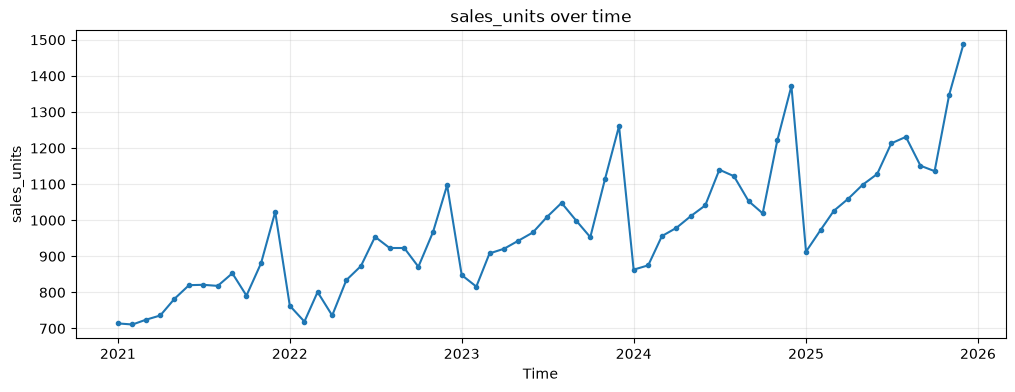

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df[time_col], df[target_col], marker="o", markersize=3)
plt.title(f"{target_col} over time")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.grid(alpha=0.25)
plt.show()


### Student questions
1. Does the order of rows matter here? Why?
2. Do you see a trend?
3. Do you see a repeating pattern?
4. Are there unusual observations?
5. What would go wrong if we randomly shuffled these rows before splitting?


## 6. Chronological train/test split


In [7]:
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Test observations    :", len(test))
print("Last train time       :", train[time_col].max())
print("First test time       :", test[time_col].min())


Training observations: 48
Test observations    : 12
Last train time       : 2024-12-01 00:00:00
First test time       : 2025-01-01 00:00:00


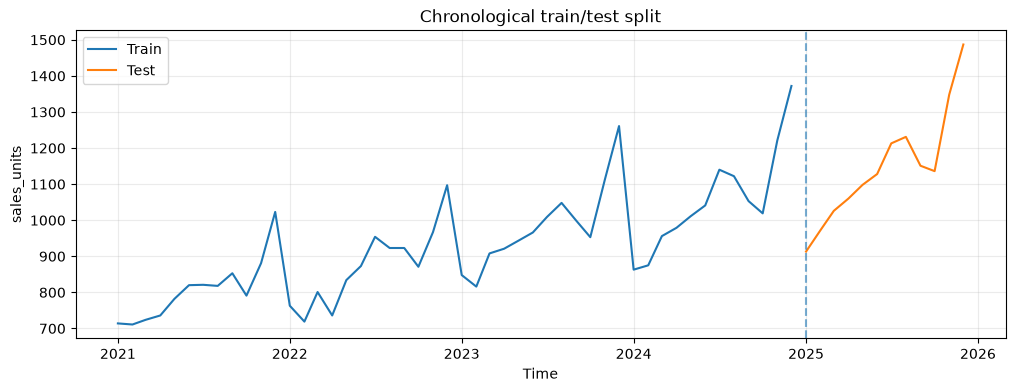

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(train[time_col], train[target_col], label="Train")
plt.plot(test[time_col], test[target_col], label="Test")
plt.axvline(test[time_col].iloc[0], linestyle="--", alpha=0.6)
plt.title("Chronological train/test split")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Naïve forecast baseline

A simple naïve forecast uses the **last observed training value** as the forecast for future observations.

A more advanced model should be compared against a simple baseline rather than judged only by how impressive its plot looks.


In [9]:
last_train_value = train[target_col].iloc[-1]
test["naive_forecast"] = last_train_value

test[[time_col, target_col, "naive_forecast"]].head()


,month,sales_units,naive_forecast
48,2025-01-01,913,1372
49,2025-02-01,973,1372
50,2025-03-01,1026,1372
51,2025-04-01,1060,1372
52,2025-05-01,1098,1372


## 8. Evaluate the baseline


In [10]:
actual = test[target_col].to_numpy()
pred = test["naive_forecast"].to_numpy()

mae = np.mean(np.abs(actual - pred))
rmse = np.sqrt(np.mean((actual - pred) ** 2))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE : 244.17
RMSE: 271.58


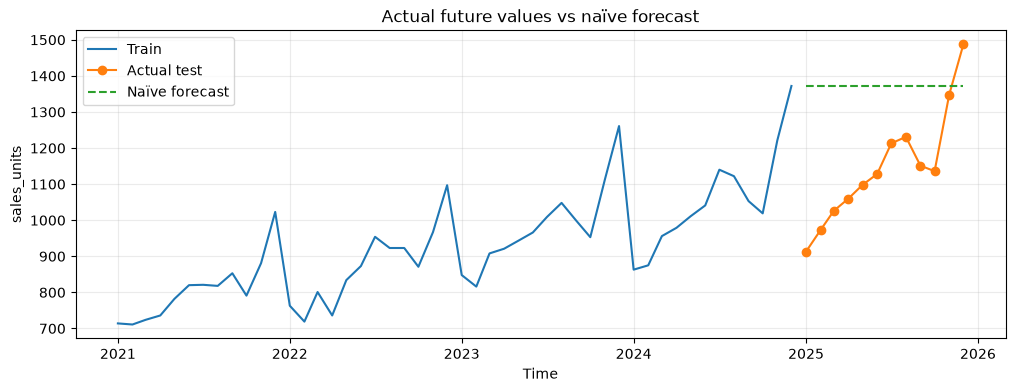

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(train[time_col], train[target_col], label="Train")
plt.plot(test[time_col], test[target_col], label="Actual test", marker="o")
plt.plot(test[time_col], test["naive_forecast"], label="Naïve forecast", linestyle="--")
plt.title("Actual future values vs naïve forecast")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Compare with last semester's Predictive Analytics

Discuss with your group:

- In ordinary predictive analytics, what did `X` and `y` usually look like?
- Here, why is **time** special?
- Why should training observations come before test observations?
- What information did the naïve forecast use?
- Would random train/test splitting leak future information?


## 10. Optional: lag-1 relationship

This is only a first look at dependence over time.  
Later in TSA, you will study lag plots, autocorrelation (ACF), stationarity, AR/MA/ARIMA and seasonal models in more depth.


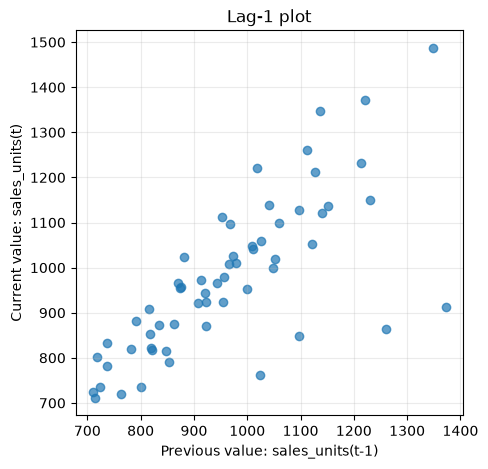

In [12]:
lag_df = df[[target_col]].copy()
lag_df["lag_1"] = lag_df[target_col].shift(1)

plt.figure(figsize=(5, 5))
plt.scatter(lag_df["lag_1"], lag_df[target_col], alpha=0.7)
plt.xlabel(f"Previous value: {target_col}(t-1)")
plt.ylabel(f"Current value: {target_col}(t)")
plt.title("Lag-1 plot")
plt.grid(alpha=0.25)
plt.show()


## Exit ticket

Write 3 sentences:

1. **A time series is different because...**
2. **Random shuffling is risky because...**
3. **A baseline forecast is useful because...**
